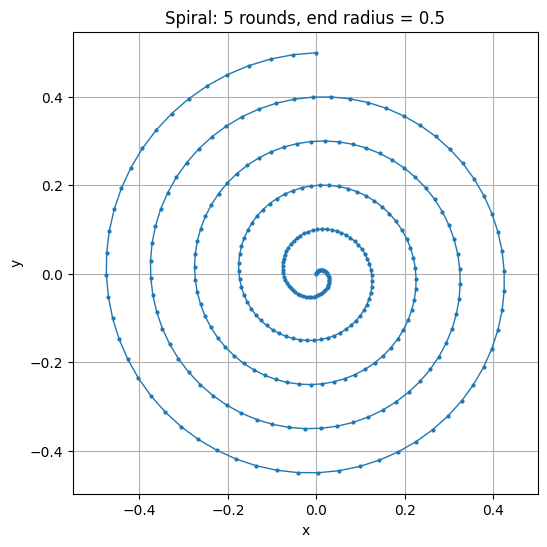

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spiral(n=200, rounds=3, rad_end=0.9):
    """
    Generate x,y coordinates for a spiral path in the x–y plane.
      - n: number of points
      - rounds: how many full 2π rotations
      - rad_end: final radius (if we start from 0 up to rad_end)
    """
    # t goes from 0 to 1
    t = 1 - np.linspace(0, 1, n)

    # tt goes from 0 up to rounds * 2π
    tt = t * rounds * 2 * np.pi
    
    # rad can grow from 0 to rad_end (adjust the formula if you want to shrink instead)
    rad = t * rad_end

    # parametric equations
    x = np.sin(tt) * rad
    y = np.cos(tt) * rad

    return x, y

# Adjust these parameters to see different spirals
n_points = 300
num_rounds = 5
final_radius = 0.5

x_vals, y_vals = generate_spiral(n=n_points, rounds=num_rounds, rad_end=final_radius)

plt.figure(figsize=(6, 6))
plt.plot(x_vals, y_vals, marker='o', markersize=2, linewidth=1)
plt.axis('equal')  # make x and y scales equal
plt.title(f"Spiral: {num_rounds} rounds, end radius = {final_radius}")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


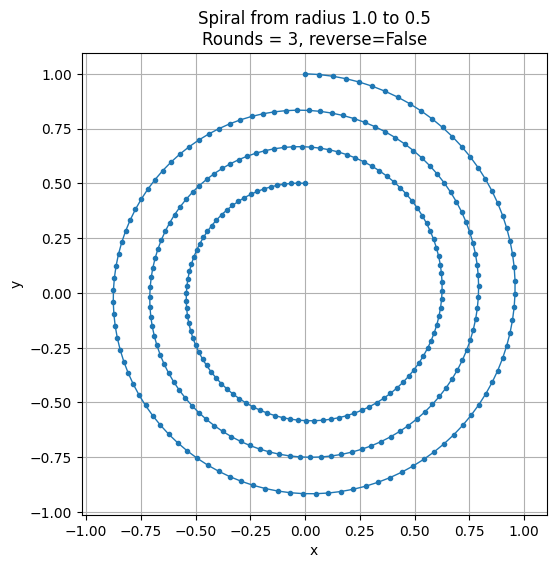

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spiral(n=200, rounds=3, r_start=1.0, r_end=0.1, reverse=False):
    """
    Generate x,y coordinates for a spiral path in the x–y plane, where the radius
    linearly interpolates from r_start to r_end.

    Parameters
    ----------
    n : int
        Number of points.
    rounds : int
        Number of full 2π rotations.
    r_start : float
        Starting radius.
    r_end : float
        Ending radius.
    reverse : bool
        If True, t will go from 1 to 0 (i.e., the spiral goes 'inward' in the
        opposite direction). Otherwise, t goes from 0 to 1.

    Returns
    -------
    x, y : np.ndarray
        Arrays of length n containing the x and y coordinates.
    """

    # t goes from 0..1 or 1..0 depending on `reverse`
    t = np.linspace(0, 1, n)
    if reverse:
        t = 1 - t  # flips the direction

    # Param for angular rotation goes from 0 up to rounds * 2π
    tt = t * rounds * 2 * np.pi

    # Radius linearly interpolates from r_start to r_end
    rad = r_start + (r_end - r_start) * t

    # Spiral equations
    x = np.sin(tt) * rad
    y = np.cos(tt) * rad

    return x, y

# ---------------------------------------------------------
# Example usage / Quick demo
# ---------------------------------------------------------
if __name__ == "__main__":
    n_points   = 300
    num_rounds = 3
    start_rad  = 1.0
    end_rad    = 0.5
    do_reverse = False  # try True to flip the spiral direction

    x_vals, y_vals = generate_spiral(n=n_points,
                                     rounds=num_rounds,
                                     r_start=start_rad,
                                     r_end=end_rad,
                                     reverse=do_reverse)

    plt.figure(figsize=(6, 6))
    plt.plot(x_vals, y_vals, marker='o', markersize=3, linewidth=1)
    plt.axis('equal')
    plt.title(f"Spiral from radius {start_rad} to {end_rad}\n"
              f"Rounds = {num_rounds}, reverse={do_reverse}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.show()


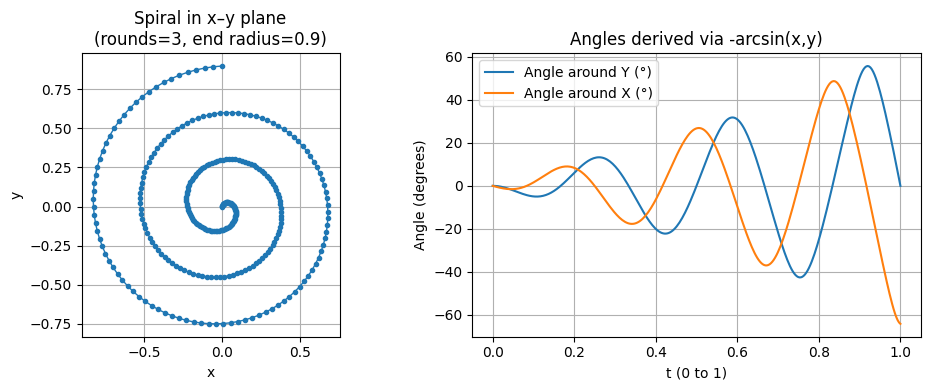

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_spiral(n=200, rounds=3, rad_end=0.9):
    """
    Generate x,y coordinates for a spiral path in the x–y plane.
      - n: number of points
      - rounds: how many full 2π rotations
      - rad_end: final radius (if starting from 0 up to rad_end)
    """
    # t goes from 0 to 1
    t = np.linspace(0, 1, n)
    
    # tt goes from 0 up to rounds * 2π
    tt = t * rounds * 2 * np.pi
    
    # rad grows linearly from 0 to rad_end (could also shrink or be another function)
    rad = t * rad_end
    
    # Parametric equations: spiral in x–y
    x = np.sin(tt) * rad
    y = np.cos(tt) * rad
    
    return t, x, y

if __name__ == "__main__":
    # Parameters
    n_points   = 300   # number of steps
    num_rounds = 3     # how many spiral rotations
    final_rad  = 0.9   # final radius (start from 0 -> 0.9)

    # Generate the spiral
    t, x_vals, y_vals = generate_spiral(n_points, num_rounds, final_rad)

    # ----------------------------------------------------
    # 1) Compute angles using arcsin
    #    arcsin(x), arcsin(y) should be in [-π/2, π/2], so it’s safe if |x|,|y| ≤ 1.
    #    We use np.clip(...) just to avoid any tiny floating errors beyond [-1, 1].
    # ----------------------------------------------------
    x_clipped = np.clip(x_vals, -1, 1)
    y_clipped = np.clip(y_vals, -1, 1)
    
    # Angle around Y-axis (based on x)
    angleY_deg = -np.arcsin(x_clipped) * 180.0 / np.pi
    
    # Angle around X-axis (based on y)
    angleX_deg = -np.arcsin(y_clipped) * 180.0 / np.pi

    # ----------------------------------------------------
    # 2) Plot the results
    # ----------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # (A) Spiral path in x–y plane
    axes[0].plot(x_vals, y_vals, marker='o', markersize=3, linewidth=1)
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].set_title(f"Spiral in x–y plane\n(rounds={num_rounds}, end radius={final_rad})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].grid(True)

    # (B) Angles over t
    axes[1].plot(t, angleY_deg, label='Angle around Y (°)')
    axes[1].plot(t, angleX_deg, label='Angle around X (°)')
    axes[1].set_title("Angles derived via -arcsin(x,y)")
    axes[1].set_xlabel("t (0 to 1)")
    axes[1].set_ylabel("Angle (degrees)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


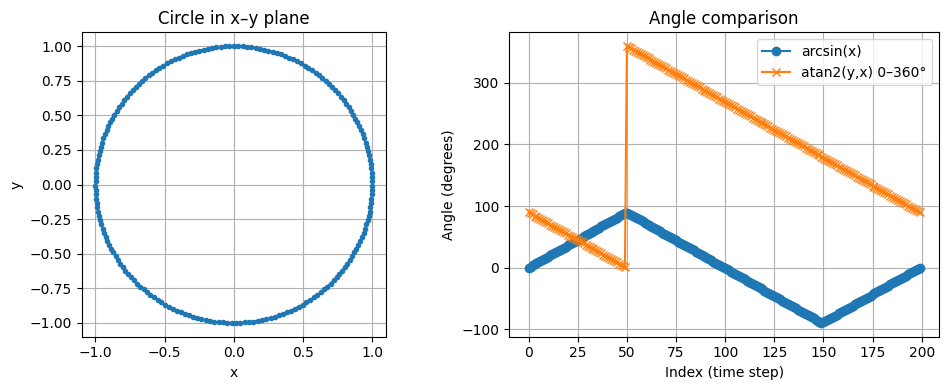

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a simple circle or spiral
n = 200
t = np.linspace(0, 1, n)
# Just do 1 round for simplicity
rounds = 1
tt = rounds * 2 * np.pi * t

# Circle of radius 1
rad = 1.0
x = np.sin(tt) * rad
y = np.cos(tt) * rad

# 1) angle via arcsin -> WRONG for full 0–360, only covers -90..+90
# We'll do arcsin(x) just as an example
angle_arcsin = np.degrees(np.arcsin(np.clip(x, -1, 1)))

# 2) angle via arctan2 -> covers full circle -180..+180
angle_atan2 = np.degrees(np.arctan2(y, x))
angle_atan2_0_360 = (angle_atan2 + 360) % 360

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# (A) Plot the circle
ax[0].plot(x, y, '-o', markersize=3)
ax[0].set_aspect('equal', 'box')
ax[0].set_title("Circle in x–y plane")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].grid(True)

# (B) Compare angles
ax[1].plot(angle_arcsin, label="arcsin(x)", marker='o')
ax[1].plot(angle_atan2_0_360, label="atan2(y,x) 0–360°", marker='x')
ax[1].set_title("Angle comparison")
ax[1].set_xlabel("Index (time step)")
ax[1].set_ylabel("Angle (degrees)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()
